In [1]:
%load_ext autoreload
%autoreload 2

In [23]:
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier

from agg import build_all_channel_aggregates, compute_liquidity_signals
from notebook_shared import SharedNotebook


In [24]:
shd = SharedNotebook(algorithm=LGBMClassifier())
def wrangle(is_train: bool=True):
    df_to_use = pd.DataFrame()
    if is_train:
        shd.read_dataset("Train.csv", is_train=is_train)
        df_to_use = shd.train_df if shd.train_df is not None else pd.DataFrame()
    else:
        shd.read_dataset("Test.csv", is_train=is_train)
        df_to_use = shd.test_df if shd.test_df is not None else pd.DataFrame()

    # Month over month calculations
    running_df = shd.calculate_monthovermonth(["total_value", "highest_amount"])

    # Avg mom calculations (normally calculated inside the notebook)
    print("Avg mom calculations....")
    if df_to_use is not None:
        av_mom_df = shd.feature_pipeline.bal_avg_mom_calculations(df_to_use)
    else:
        raise ValueError("dataframe to use is None")

    running_df = pd.concat([running_df, av_mom_df], axis=1)

    # Removing autocorrelation features
    print("Removing autocorrelation features....")
    shd.remove_correlated_features(running_df)


    # Joining with the existing original dataset
    print("Aggregation, Liquidity signals andJoining with the existing original dataset....")
    train_df = pd.concat([df_to_use, running_df], axis=1)
    out = build_all_channel_aggregates(df_to_use)
    sig = compute_liquidity_signals(df_to_use, out)
    train_df = pd.concat([train_df, sig], axis=1)

    # If there is any numpy infite number raise exception
    if train_df.isin([np.inf, -np.inf]).any().sum():
        raise ValueError("There is any numpy infite number. Algorithm may fail to train.")

    # Remove features defined to be less useful
    print("Removing features defined to be less useful....")
    shd.define_features_to_remove(train_df)

    return train_df


In [25]:
running_df = wrangle()
running_df.head(2)


Is self.test available:  False
Is it training mode:  True
['m1_paybill_total_value', 'm2_paybill_total_value', 'm3_paybill_total_value', 'm4_paybill_total_value', 'm5_paybill_total_value', 'm6_paybill_total_value', 'm1_merchantpay_total_value', 'm2_merchantpay_total_value', 'm3_merchantpay_total_value', 'm4_merchantpay_total_value', 'm5_merchantpay_total_value', 'm6_merchantpay_total_value', 'm1_received_total_value', 'm2_received_total_value', 'm3_received_total_value', 'm4_received_total_value', 'm5_received_total_value', 'm6_received_total_value', 'm1_deposit_total_value', 'm2_deposit_total_value', 'm3_deposit_total_value', 'm4_deposit_total_value', 'm5_deposit_total_value', 'm6_deposit_total_value', 'm1_withdraw_total_value', 'm2_withdraw_total_value', 'm3_withdraw_total_value', 'm4_withdraw_total_value', 'm5_withdraw_total_value', 'm6_withdraw_total_value']
Is self.test available:  False
Is it training mode:  True
['m1_paybill_highest_amount', 'm2_paybill_highest_amount', 'm3_payb

,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_total_value,m1_paybill_highest_amount,...,withdraw_share_of_outflow,paybill_share_of_outflow,total_outflow_value,total_inflow_value,outflow_to_inflow_ratio,outflow_channel_entropy,withdraw_active_months,paybill_active_months,withdraw_share_trend,paybill_share_trend
0,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,58372.55,5352.41,...,0.498137,0.325910,332489.28,590474.93,0.563088,1.106951,1,4,0.622915,-0.246824
1,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,0.00,0.00,...,0.732322,0.126699,884314.06,1286319.71,0.687476,0.838202,6,4,-0.205591,0.143456


In [ ]:
from build import ModelPipeline
from sklearn.model_selection import train_test_split

def prepare_df(X, is_train=True):
    if not is_train:
        X_test, _ = shd.feature_pipeline.transform(X, is_train=is_train)
        X_test = X_test.loc[:, ~X_test.columns.duplicated()]
        shd.remove_features_definedby_algorithm_gain(X_test, None)
        shd.remove_netflow_features(X_test, None)
        shd.find_and_remove_mom_features(X_test)
        return X_test
    else:
        raw_train, raw_val = train_test_split(
            X,
            test_size=0.2,
            stratify=X[shd.feature_pipeline.target_col],
            random_state=42,
        )

        X_train, y_train = shd.feature_pipeline.transform(raw_train)
        X_val, y_val = shd.feature_pipeline.transform(raw_val)
        X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

        if y_train is None:
            raise ValueError("y_train is None")
        
        pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

        # Get dulicated columns and remain with one of them
        X_train, X_val = X_train.loc[:, ~X_train.columns.duplicated()], X_val.loc[:, ~X_val.columns.duplicated()]
        shd.remove_features_definedby_algorithm_gain(X_train, X_val)
        shd.remove_netflow_features(X_train, X_val)
        shd.find_and_remove_mom_features(X_train)
        shd.find_and_remove_mom_features(X_val)

        return X_train, y_train, X_val, y_val, pos_weight

In [27]:
X_train, y_train, X_val, y_val, pos_weight = prepare_df(running_df)
X_train.head(2)

,arpu,age,x_90_d_activity_rate,m1_paybill_total_value,m1_paybill_highest_amount,m2_paybill_total_value,m2_paybill_highest_amount,m3_paybill_total_value,m3_paybill_highest_amount,m4_paybill_total_value,...,inflow_slope_6m,outflow_slope_6m,bal_m1_m6_ratio,m1_cashout_intensity,avg_recent3_cashout,avg_old3_cashout,bal_std_dev_3m,bal_std_dev_6m,recent3_avg_balance,old3_avg_balance
16946,3187.16,38,0.4573,0.0,0.00,0.0,0.0,427.23,423.38,0.0,...,-787.396571,-90.661429,0.330573,0.000000,3364.713333,2847.010000,255.729161,613.381487,948.113333,1621.750000
39245,4769.99,45,0.5526,9075.4,7483.94,0.0,0.0,26574.00,1923.44,0.0,...,-7646.985143,30217.382000,1.348613,11.275563,199246.806667,46991.803333,1932.324033,2572.315753,10304.526667,6598.206667


In [28]:
model = shd.tune_lgbm(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Best Parameters: {'colsample_bytree': 0.5, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 1000, 'num_leaves': 15, 'objective': 'binary', 'reg_alpha': 10, 'reg_lambda': 20, 'scale_pos_weight': 2.8333333333333335}
Best CV Score: 0.8981


In [29]:
train_preds, val_preds = shd.run_predictions(model, X_train, X_val, y_train, y_val)


Train ROC:  0.9760601485906863
Val ROC:  0.8944137254901962
Val Log Loss:  0.28859296578280746


Classification report: 
               precision    recall  f1-score   support

           0       0.93      0.92      0.93      6800
           1       0.58      0.63      0.61      1200

    accuracy                           0.88      8000
   macro avg       0.76      0.78      0.77      8000
weighted avg       0.88      0.88      0.88      8000



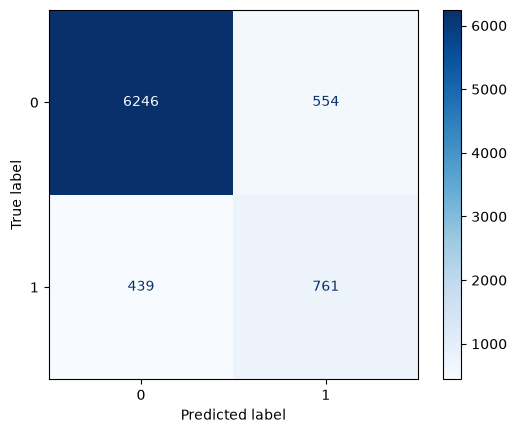

In [30]:
shd.build_cm(y_val, val_preds)

In [21]:
clb_model = shd.calibrate_model(model, X_train, y_train)
val_pred = shd.run_calibrated_predictions(clb_model, X_val)
val_pred

array([0.00869951, 0.06999349, 0.75492415, ..., 0.00309922, 0.0045118 ,
       0.11270173], shape=(8000,))

In [22]:
shd.display_val_prediction_stats(val_pred, y_val)

Val ROC:  0.8944926470588234
Val Log Loss:  0.26572430555966015


In [108]:
# Do the same process for test dataframe
shd = SharedNotebook(algorithm=LGBMClassifier(), is_train=False)
test_running_df = wrangle(is_train=False)
test_running_df.shape

Reaing test dataset
Is self.test available:  True
Is it training mode:  False
['m1_paybill_total_value', 'm2_paybill_total_value', 'm3_paybill_total_value', 'm4_paybill_total_value', 'm5_paybill_total_value', 'm6_paybill_total_value', 'm1_merchantpay_total_value', 'm2_merchantpay_total_value', 'm3_merchantpay_total_value', 'm4_merchantpay_total_value', 'm5_merchantpay_total_value', 'm6_merchantpay_total_value', 'm1_received_total_value', 'm2_received_total_value', 'm3_received_total_value', 'm4_received_total_value', 'm5_received_total_value', 'm6_received_total_value', 'm1_deposit_total_value', 'm2_deposit_total_value', 'm3_deposit_total_value', 'm4_deposit_total_value', 'm5_deposit_total_value', 'm6_deposit_total_value', 'm1_withdraw_total_value', 'm2_withdraw_total_value', 'm3_withdraw_total_value', 'm4_withdraw_total_value', 'm5_withdraw_total_value', 'm6_withdraw_total_value']
Is self.test available:  True
Is it training mode:  False
['m1_paybill_highest_amount', 'm2_paybill_highe

(30000, 182)

In [111]:
X_test = prepare_df(test_running_df, is_train=False)
X_test.head(2)

,arpu,age,x_90_d_activity_rate,m1_paybill_total_value,m1_paybill_highest_amount,m2_paybill_total_value,m2_paybill_highest_amount,m3_paybill_total_value,m3_paybill_highest_amount,m4_paybill_total_value,...,inflow_slope_6m,outflow_slope_6m,bal_m1_m6_ratio,m1_cashout_intensity,avg_recent3_cashout,avg_old3_cashout,bal_std_dev_3m,bal_std_dev_6m,recent3_avg_balance,old3_avg_balance
0,2653.88,47,0.6905,0.00,0.00,0.0,0.0,21341.77,5938.05,7831.85,...,-14924.674286,1727.573714,0.441833,7.900611,61776.256667,63108.470000,5251.054242,3923.410588,11300.963333,13561.640000
1,2653.88,47,0.6905,89420.67,4231.17,0.0,0.0,0.00,0.00,19568.77,...,-37334.222000,13836.636286,1.916536,14.195614,207724.480000,147963.236667,3572.332030,3437.153505,7060.723333,6922.753333


In [112]:
test_pred = shd.run_calibrated_predictions(clb_model, X_test)

In [115]:
shd.save_submission_file(test_running_df, test_pred)

Submission file saved!


,ID,Target
0,ID_ED91AC7A28,0.017364
1,ID_29975A9C7E,0.047352
2,ID_F59CE25650,0.011864
3,ID_E875F68D1A,0.000736
4,ID_2902B1C0D0,0.007180
...,...,...
29995,ID_3C7CF79AEE,0.006857
29996,ID_F1651E73C4,0.008814
29997,ID_FD3F0934CA,0.179146
29998,ID_DA6916D6C7,0.007247


In [39]:
rfc = shd.tune_random_forest(X_train, y_train)

Fitting 2 folds for each of 2 candidates, totalling 4 fits
Best Parameters: {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 9, 'max_features': 'sqrt', 'max_leaf_nodes': 300, 'n_estimators': 1000, 'oob_score': True}
Best CV Score: -0.4314


In [50]:
train_preds2, val_preds2 = shd.run_predictions(rfc, X_train, X_val, y_train, y_val)
shd.display_val_prediction_stats(val_preds2, y_val)


Train ROC:  0.9532735064338235
Val ROC:  0.8658023284313726
Val Log Loss:  0.44989670860061165
Val ROC:  0.8658023284313726
Val Log Loss:  0.44989670860061165


In [46]:
type(y_val)

pandas.Series

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC


estimators = [
    ('rf', rfc),
    ('lgbm', model),
]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=SVC(),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1,
)
stacking.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('rf', ...), ('lgbm', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",SVC()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,) or list of ndarray if `y` is of type `""multilabel-indicator""`.Class labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[RandomForestC...ndom_state=42), LGBMClassifie... verbosity=-1)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U36](133,)","['arpu','age','x_90_d_acti

In [54]:
# Save stacked model for further exploration
import pickle
with open('stacked_model.pkl', 'wb') as f:
    pickle.dump(stacking, f)

In [56]:
ypred3 = stacking.predict(X_val)

shd.display_val_prediction_stats(ypred3, y_val)

Val ROC:  0.6998529411764706
Val Log Loss:  3.9467800461083278


In [57]:
ypred4 = stacking.predict(X_train)

shd.display_val_prediction_stats(ypred4, y_train)


Val ROC:  0.8173161764705883
Val Log Loss:  2.268497435177561


In [59]:
stacking.predict_proba(X_val)


AttributeError: This 'StackingClassifier' has no attribute 'predict_proba'